In [34]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
%matplotlib inline

In [41]:
data = pd.read_csv("./amazon.csv")

data['discount_percentage'] = data['discount_percentage'].str.replace('%', '').astype(float)
data['rating_count'] = data['rating_count'].str.replace(',', '').astype(float)
data['rating'] = data['rating'].str.replace('|', '')
data = data.replace('', np.nan, regex=True)
data['rating'] = data['rating'].astype(float)
data_clean = data.drop(columns=["review_title", "review_content", "img_link", "product_link"])
data_clean = data_clean.dropna()
data_clean.to_csv("./amazon_cleaned.csv")
print('Dataset cleaned and saved to ./amazon_cleaned.csv')

percentage = 0.3
data_clean[:int(len(data) * percentage)]

Dataset cleaned and saved to ./amazon_cleaned.csv


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K..."
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY..."
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61.0,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R..."
...,...,...,...,...,...,...,...,...,...,...,...,...
436,B09T2S8X9C,"Redmi Note 11 Pro + 5G (Stealth Black, 8GB RAM...",Electronics|Mobiles&Accessories|Smartphones&Ba...,"₹22,999","₹28,999",21.0,3.9,25824.0,Superior performance with Snapdragon 695 5G. W...,"AHALPOEUQFGXEZR6NQ64ZI3EIYXA,AFJEOV652OA6P6CPX...","Indro,Bhavesh Bodat,Amazon Customer,Ambalika S...","R1S5FUVJK5BDKV,R10T102N4IHERO,R1QALRWVTEDXMH,R..."
437,B07S9S86BF,boAt Bassheads 242 in Ear Wired Earphones with...,"Electronics|Headphones,Earbuds&Accessories|Hea...",₹599,"₹1,490",60.0,4.1,161679.0,Fly into your workouts with precise tones that...,"AFG3EU556AXTCQXSTGYD2ACM5H6Q,AF65DDTW2IWXZ4TJJ...","Tanu,THENNARASU,Gatij saini,uday,Rohit,Akshat ...","R2WQHYFXQ5BCCA,R3BU0MFK2ORFS6,R2A3HU0CB8SUQ4,R..."
438,B07N8RQ6W7,Portronics MODESK POR-122 Universal Mobile Tab...,Electronics|Mobiles&Accessories|MobileAccessor...,₹134,₹699,81.0,4.1,16685.0,MoDesk - a Premium Quality Mobile Holders for ...,"AE55KTFVNXYFD5FPYWP2OUPEYNPQ,AE7UFVGPV7KYAP74U...","Sethu madhav,Prajwala,Amazon Customer,Manikand...","R23YK9FCYDZ8D5,R2FHT8TJPYXUVB,R2775SLGU24T7V,R..."
439,B09FKDH6FS,"realme narzo 50i (Mint Green, 2GB RAM+32GB Sto...",Electronics|Mobiles&Accessories|Smartphones&Ba...,"₹7,499","₹7,999",6.0,4.0,30907.0,2 GB RAM | 32 GB ROM | Expandable Upto 256 GB|...,"AFFOR2CVZKO4LFXRBJ2WEQXRHDKA,AEE5DT5BRBCBX27LO...","Aditya Jha,Aman dhiman,RAMLAL Khadav,Jagan,Meh...","R36T09OX35WPH0,R1SPKNBAZ5I7N1,R2H32V6C3AL47P,R..."


In [42]:
dt = pd.read_csv("./amazon_cleaned.csv")

min_discount = dt["discount_percentage"].min()
max_discount = dt["discount_percentage"].max()
max_rating_count = dt["rating_count"].max()

rating_max = dt["rating"].max()
rating_min = dt["rating"].min()

print(f"Product Discount Range: {min_discount} - {max_discount}")
print(f"Number of Votes Range: 0 - {max_rating_count}")
print(f"Rating Range: {rating_min} - {rating_max}")

Product Discount Range: 0.0 - 94.0
Number of Votes Range: 0 - 426973.0
Rating Range: 2.0 - 5.0


In [53]:
rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'rating')
discount = ctrl.Antecedent(np.arange(min_discount, max_discount + 1, 1), 'discount')
num_votes = ctrl.Antecedent(np.arange(0, max_rating_count + 1, 10000), 'num_votes')
prod_quat = ctrl.Consequent(np.arange(0, 6, 1), 'prod_quat')

In [54]:
rating['low'] = fuzz.trapmf(rating.universe, [0, 0, 1.5, 2.5])
rating['medium'] = fuzz.trimf(rating.universe, [2, 2.75, 3.5])
rating['high'] = fuzz.trapmf(rating.universe, [3, 4, 5, 5])

discount['small'] = fuzz.trapmf(discount.universe, [min_discount, min_discount, 30, 50])
discount['mid'] = fuzz.trimf(discount.universe, [40, 55, 70])
discount['big'] = fuzz.trapmf(discount.universe, [60, 80, max_discount, max_discount])

num_votes['few'] = fuzz.trapmf(num_votes.universe, [0, 0, 30000, 90000])
num_votes['average'] = fuzz.trimf(num_votes.universe, [80000, 100000, 300000])
num_votes['many'] = fuzz.trapmf(num_votes.universe, [200000, 400000, max_rating_count, max_rating_count])

prod_quat['low'] = fuzz.trapmf(prod_quat.universe, [0, 0, 1.5, 2.5])
prod_quat['medium'] = fuzz.trimf(prod_quat.universe, [2, 2.75, 3.5])
prod_quat['high'] = fuzz.trapmf(prod_quat.universe, [3, 4, 5, 5])

C:\Users\Jeremy\Documents\Kuliah\ML-AI\.env\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


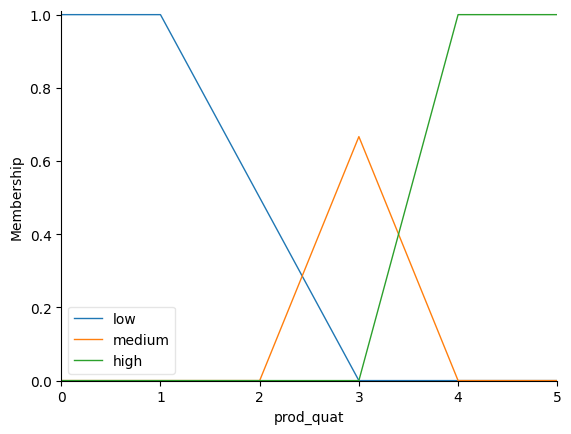

In [55]:
prod_quat.view()
plt.show()

In [56]:
rule1 = ctrl.Rule(rating['high'] & num_votes['many'], prod_quat['high'])
rule2 = ctrl.Rule(rating['medium'] & num_votes['average'], prod_quat['medium'])
rule3 = ctrl.Rule(rating['low'] & num_votes['few'], prod_quat['low'])
rule4 = ctrl.Rule(rating['high'] & discount['small'], prod_quat['high'])
rule5 = ctrl.Rule(rating['medium'] & discount['big'], prod_quat['medium'])
rule6 = ctrl.Rule(rating['low'] | num_votes['few'], prod_quat['low'])
rule7 = ctrl.Rule(rating['high'], prod_quat['high'])
rule8 = ctrl.Rule(rating['medium'], prod_quat['medium'])
rule9 = ctrl.Rule(rating['low'], prod_quat['low'])

quat_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])

In [60]:
def compute_quat(row):
    quat_sim = ctrl.ControlSystemSimulation(quat_ctrl)

    rating_value = None
    discount_value = None
    num_votes_value = None

    try:
        rating_value = row["rating"]
        discount_value = row["discount_percentage"]
        num_votes_value = row["rating_count"]

        rating_value = np.clip(rating_value, rating.universe[0], rating.universe[-1])
        discount_value = np.clip(discount_value, discount.universe[0], discount.universe[-1])
        num_votes_value = np.clip(num_votes_value, num_votes.universe[0], num_votes.universe[-1])

        quat_sim.input["rating"] = rating_value
        quat_sim.input["discount"] = discount_value
        quat_sim.input["num_votes"] = num_votes_value

        quat_sim.compute()

        return quat_sim.output["prod_quat"]

    except Exception as ex:
        print(f"Error computing for row {row.name}: {ex}")
        print(f"Inputs: Rating={rating_value}, Discount={discount_value}, Number of Votes={num_votes_value}")
        return np.nan

dt['quat_val_score'] = data.apply(compute_quat, axis=1)
dt.head()

,Unnamed: 0,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,quat_val_score
0,0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...",2.428571
1,1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...",2.590153
2,2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...",2.365292
3,3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...",4.222222
4,4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61.0,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...",2.428571


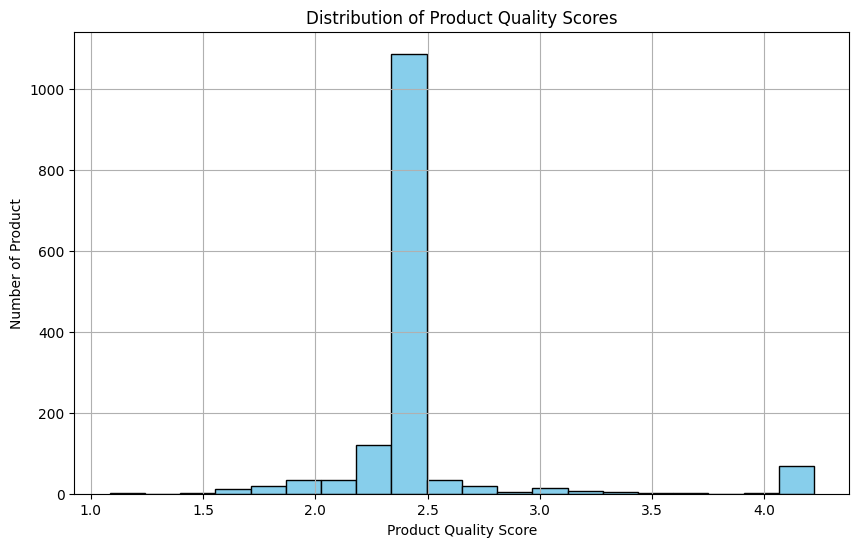

In [61]:
plt.figure(figsize=(10,6))
plt.hist(dt['quat_val_score'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Product Quality Scores')
plt.xlabel('Product Quality Score')
plt.ylabel('Number of Product')
plt.grid(True)
plt.show()